In [21]:
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
tfd = tfp.distributions
tfb = tfp.bijectors

In [3]:
# 1. Generate synthetic data: y = 2.0 * x - 1.0 + noise
tf.random.set_seed(42)
x_data = tf.linspace(-2.0, 2.0, 50)
y_data = 2.0 * x_data - 1.0 + tf.random.normal([50], stddev=0.5)

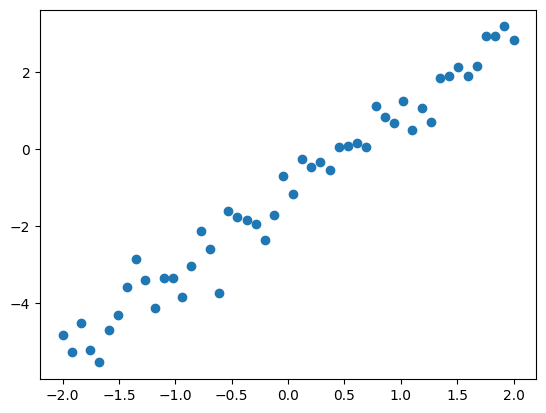

In [5]:
plt.figure()
plt.scatter(x_data, y_data)
plt.show()

In [6]:
# 2. Define the Target Log Prob function (Unnormalized Joint Posterior)
def target_log_prob(slope, intercept):
    # Prior distributions
    prior_slope = tfd.Normal(loc=0.0, scale=10.0)
    prior_intercept = tfd.Normal(loc=0.0, scale=10.0)
    
    # Likelihood function
    mean = slope * x_data + intercept
    likelihood = tfd.Normal(loc=mean, scale=0.5)
    
    # Return total joint log likelihood (Priors + Likelihood)
    return (
        prior_slope.log_prob(slope) +
        prior_intercept.log_prob(intercept) +
        tf.reduce_sum(likelihood.log_prob(y_data))
    )

In [7]:
# 3. Configure the MCMC Sampler (Hamiltonian Monte Carlo with Adaptive Step Size)
num_results = 8000
num_burnin_steps = 2000

In [8]:
# Base HMC kernel
hmc_kernel = tfp.mcmc.HamiltonianMonteCarlo(
    target_log_prob_fn=target_log_prob,
    step_size=0.05,
    num_leapfrog_steps=3
)

In [9]:
# Adaptive step size kernel wrapper
adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    inner_kernel=hmc_kernel,
    num_adaptation_steps=int(num_burnin_steps * 0.8)
)

In [ ]:
# 4. Run the Chain
@tf.function(autograph=False, jit_compile=True)
def run_chain():
    # Initial state for parameters [slope, intercept]
    initial_state = [tf.constant(0.0), tf.constant(0.0)]
    
    samples, kernel_results = tfp.mcmc.sample_chain(
        num_results=num_results,
        num_burnin_steps=num_burnin_steps,
        current_state=initial_state,
        kernel=adaptive_hmc,
        trace_fn=lambda _, pkr: pkr.inner_results.is_accepted
    )
    return samples

In [11]:
# Execute sampling
slope_samples, intercept_samples = run_chain()

In [12]:
# 5. Output posterior estimates
print("Posterior Mean Slope:", tf.reduce_mean(slope_samples).numpy())
print("Posterior Mean Intercept:", tf.reduce_mean(intercept_samples).numpy())

Posterior Mean Slope: 2.0842435
Posterior Mean Intercept: -1.1295325


In [13]:
slope_samples

<tf.Tensor: shape=(8000,), dtype=float32, numpy=
array([1.986969 , 2.009946 , 2.009946 , ..., 2.0770736, 2.0930905,
       2.022933 ], dtype=float32)>

In [14]:
intercept_samples

<tf.Tensor: shape=(8000,), dtype=float32, numpy=
array([-1.2016468, -1.2363191, -1.2363191, ..., -1.124671 , -1.1735692,
       -1.142109 ], dtype=float32)>

In [16]:
# Convert TensorFlow tensors to NumPy arrays for plotting
slope_samples_np = slope_samples.numpy()
intercept_samples_np = intercept_samples.numpy()
x_np = x_data.numpy()
y_np = y_data.numpy()

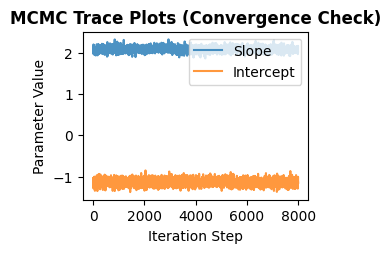

In [17]:
# -------------------------------------------------------------------
# 1. Trace Plot: Check for MCMC Chain Convergence
# -------------------------------------------------------------------
plt.subplot(2, 2, 1)
plt.plot(slope_samples_np, label="Slope", alpha=0.8, color="#1f77b4")
plt.plot(intercept_samples_np, label="Intercept", alpha=0.8, color="#ff7f0e")
plt.title("MCMC Trace Plots (Convergence Check)", fontsize=12, fontweight="bold")
plt.xlabel("Iteration Step")
plt.ylabel("Parameter Value")
plt.legend(loc="upper right")

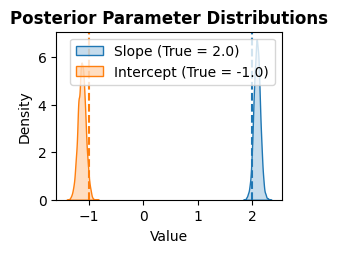

In [20]:
# -------------------------------------------------------------------
# 2. Marginal Posterior Distributions (Histograms + KDE)
# -------------------------------------------------------------------
plt.subplot(2, 2, 2)
sns.kdeplot(slope_samples_np, fill=True, label="Slope (True = 2.0)", color="#1f77b4")
sns.kdeplot(intercept_samples_np, fill=True, label="Intercept (True = -1.0)", color="#ff7f0e")
plt.axvline(x=2.0, color="#1f77b4", linestyle="--", linewidth=1.5)
plt.axvline(x=-1.0, color="#ff7f0e", linestyle="--", linewidth=1.5)
plt.title("Posterior Parameter Distributions", fontsize=12, fontweight="bold")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend(loc="upper right")

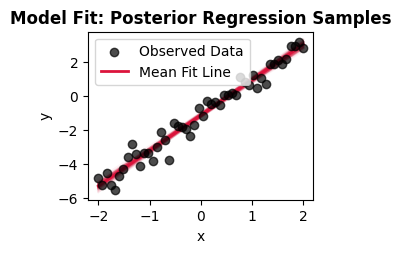

In [22]:
# -------------------------------------------------------------------
# 3. Posterior Regression Lines vs. Data Points
# -------------------------------------------------------------------
plt.subplot(2, 2, 3)
plt.scatter(x_np, y_np, color="black", alpha=0.7, label="Observed Data", zorder=3)

# Draw 100 sampled lines from the posterior distribution
num_draws = 100
idx = np.random.choice(len(slope_samples_np), size=num_draws, replace=False)

for i in idx:
    y_draw = slope_samples_np[i] * x_np + intercept_samples_np[i]
    plt.plot(x_np, y_draw, color="crimson", alpha=0.05)

# Mean prediction line
mean_slope = np.mean(slope_samples_np)
mean_intercept = np.mean(intercept_samples_np)
plt.plot(x_np, mean_slope * x_np + mean_intercept, color="crimson", linewidth=2, label="Mean Fit Line")

plt.title("Model Fit: Posterior Regression Samples", fontsize=12, fontweight="bold")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left")

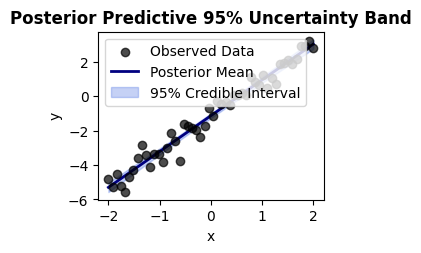

In [23]:
# -------------------------------------------------------------------
# 4. Posterior Predictive Interval (Credible Interval)
# -------------------------------------------------------------------
plt.subplot(2, 2, 4)
plt.scatter(x_np, y_np, color="black", alpha=0.7, label="Observed Data", zorder=3)

# Calculate 95% Credible Interval across the x-domain
y_post = slope_samples_np[:, np.newaxis] * x_np + intercept_samples_np[:, np.newaxis]
y_low = np.percentile(y_post, 2.5, axis=0)
y_high = np.percentile(y_post, 97.5, axis=0)

plt.plot(x_np, mean_slope * x_np + mean_intercept, color="navy", linewidth=2, label="Posterior Mean")
plt.fill_between(x_np, y_low, y_high, color="royalblue", alpha=0.3, label="95% Credible Interval")

plt.title("Posterior Predictive 95% Uncertainty Band", fontsize=12, fontweight="bold")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(loc="upper left")